C:\Users\alexo\AppData\Local\Temp\ipykernel_35988\1246241378.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None)
C:\Users\alexo\AppData\Local\Temp\ipykernel_35988\1246241378.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None)


Linear Regression - Training Accuracy: 99.42%
Linear Regression - Testing Accuracy: 98.11%
Logistic Regression - Training Accuracy: 99.55%
Logistic Regression - Testing Accuracy: 98.11%
Perceptron - Training Accuracy: 99.42%
Perceptron - Testing Accuracy: 98.35%


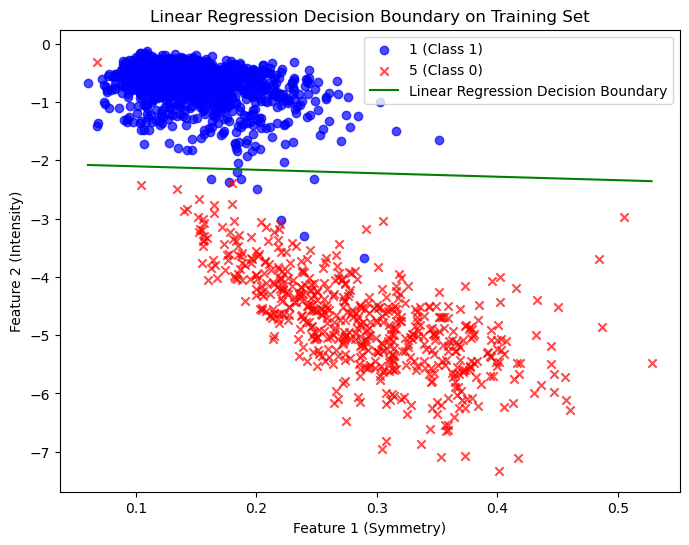

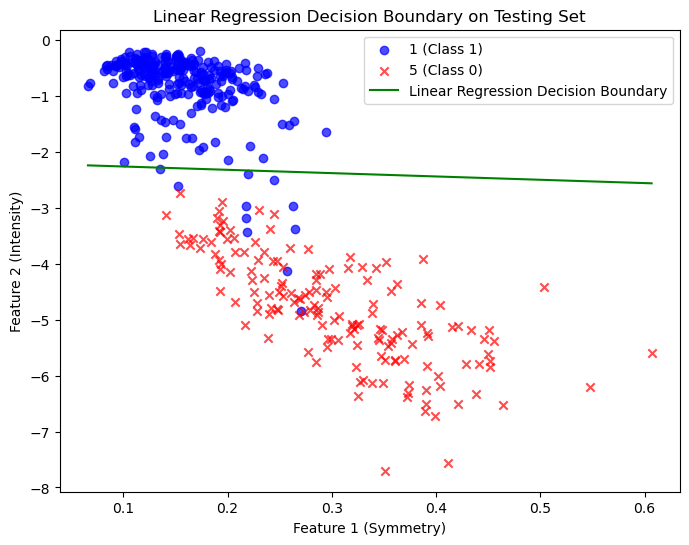

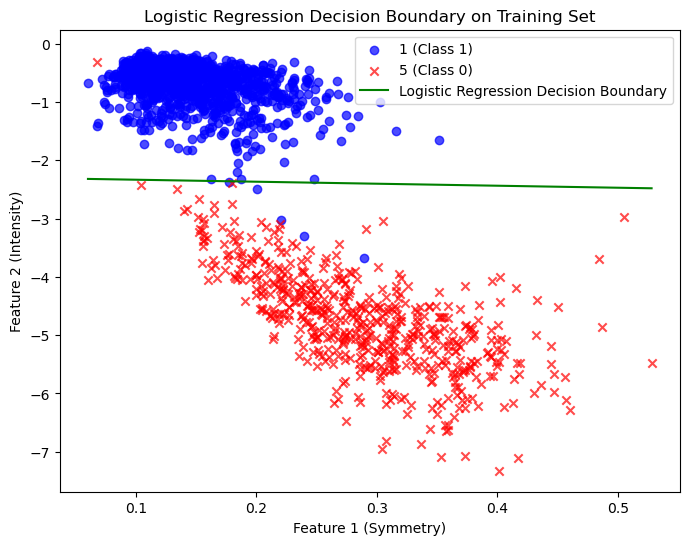

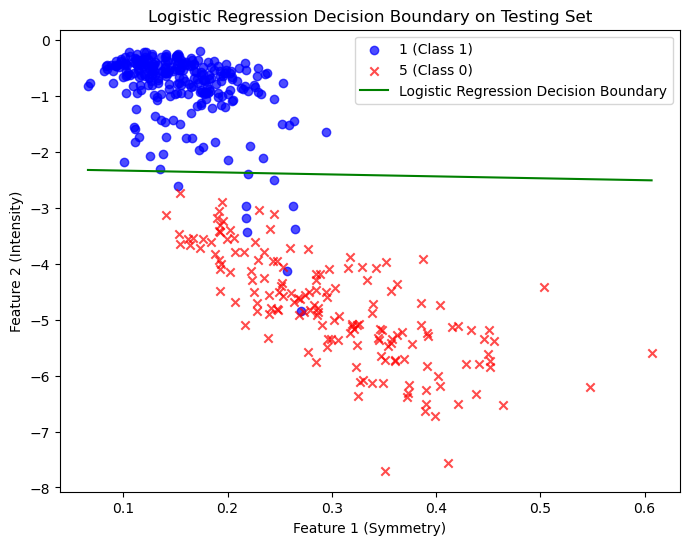

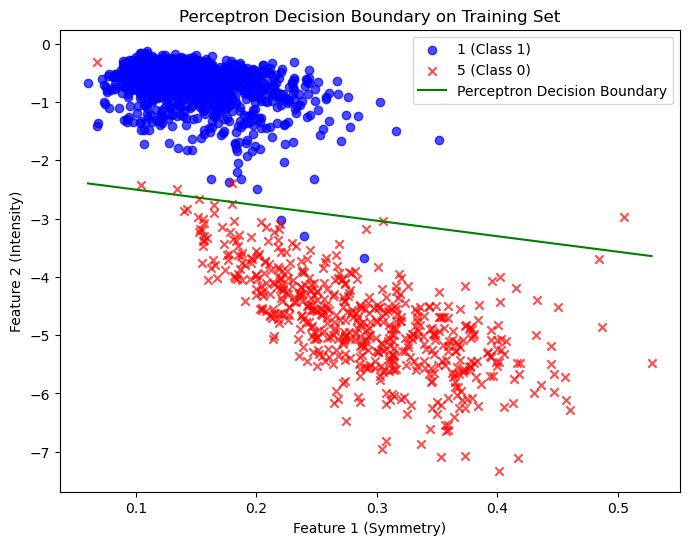

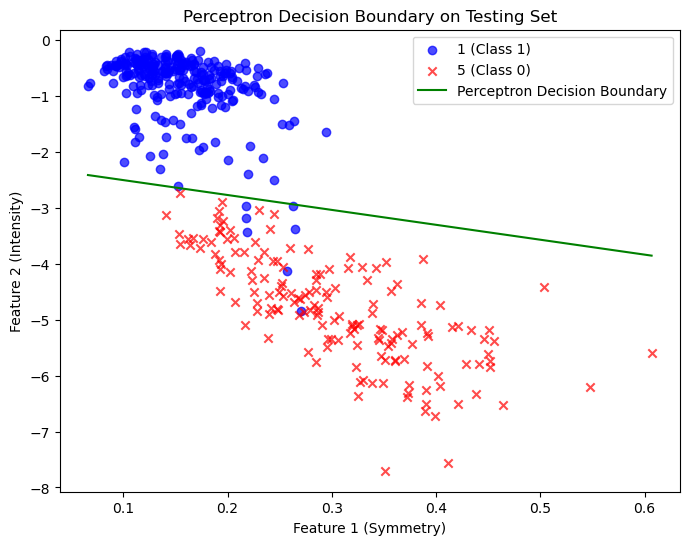

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Load and filter data function
def load_and_filter_data(file_path):
    data = pd.read_csv(file_path, delim_whitespace=True, header=None)
    data = data[(data.iloc[:, 0] == 1) | (data.iloc[:, 0] == 5)]
    data.iloc[:, 0] = data.iloc[:, 0].map({1: 1, 5: 0})
    labels = data.iloc[:, 0].values
    features = data.iloc[:, 1:].values
    return features, labels

# Load training and testing data
X_train, y_train = load_and_filter_data('features_train.txt')
X_test, y_test = load_and_filter_data('features_test.txt')

# Add bias term to features
X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

### 1. Linear Regression Model (Least Squares) with Gradient Descent ###

def linear_regression_gradient_descent(X, y, lr=0.01, iterations=1000):
    m, n = X.shape
    w = np.zeros(n)
    for _ in range(iterations):
        predictions = X @ w
        gradient = (1 / m) * X.T @ (predictions - y)
        w -= lr * gradient
    return w

w_linear = linear_regression_gradient_descent(X_train, y_train, lr=0.01, iterations=1000)

# Calculate accuracies for linear regression
y_pred_train_linear = (X_train @ w_linear >= 0.5).astype(int)
y_pred_test_linear = (X_test @ w_linear >= 0.5).astype(int)
accuracy_train_linear = accuracy_score(y_train, y_pred_train_linear)
accuracy_test_linear = accuracy_score(y_test, y_pred_test_linear)
print(f"Linear Regression - Training Accuracy: {accuracy_train_linear * 100:.2f}%")
print(f"Linear Regression - Testing Accuracy: {accuracy_test_linear * 100:.2f}%")

### 2. Logistic Regression Model with Armijo Rule Step Sizes ###

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logistic_regression_armijo(X, y, initial_lr=1.0, beta=0.5, sigma=1e-4, max_iters=1000):
    m, n = X.shape
    w = np.zeros(n)
    for _ in range(max_iters):
        predictions = sigmoid(X @ w)
        gradient = (1 / m) * X.T @ (predictions - y)
        lr = initial_lr
        while True:
            w_new = w - lr * gradient
            if (1 / m) * np.sum(-y * np.log(sigmoid(X @ w_new)) - (1 - y) * np.log(1 - sigmoid(X @ w_new))) <= \
               (1 / m) * np.sum(-y * np.log(sigmoid(X @ w)) - (1 - y) * np.log(1 - sigmoid(X @ w))) - sigma * lr * np.dot(gradient, gradient):
                break
            lr *= beta
        w = w_new
    return w

w_logistic = logistic_regression_armijo(X_train, y_train, initial_lr=1.0, beta=0.5, sigma=1e-4, max_iters=1000)

# Calculate accuracies for logistic regression
y_pred_train_logistic = (sigmoid(X_train @ w_logistic) >= 0.5).astype(int)
y_pred_test_logistic = (sigmoid(X_test @ w_logistic) >= 0.5).astype(int)
accuracy_train_logistic = accuracy_score(y_train, y_pred_train_logistic)
accuracy_test_logistic = accuracy_score(y_test, y_pred_test_logistic)
print(f"Logistic Regression - Training Accuracy: {accuracy_train_logistic * 100:.2f}%")
print(f"Logistic Regression - Testing Accuracy: {accuracy_test_logistic * 100:.2f}%")

### 3. Perceptron Algorithm ###

def perceptron(X, y, max_iters=1000, lr=0.1):
    m, n = X.shape
    w = np.zeros(n)
    y = np.where(y == 0, -1, y)
    for _ in range(max_iters):
        misclassified = 0
        for xi, yi in zip(X, y):
            if yi * (np.dot(w, xi)) <= 0:
                w += lr * yi * xi
                misclassified += 1
        if misclassified == 0:
            break
    return w

w_perceptron = perceptron(X_train, y_train, max_iters=1000, lr=0.1)

# Calculate accuracies for perceptron
y_pred_train_perceptron = (X_train @ w_perceptron >= 0).astype(int)
y_pred_test_perceptron = (X_test @ w_perceptron >= 0).astype(int)
accuracy_train_perceptron = accuracy_score(y_train, y_pred_train_perceptron)
accuracy_test_perceptron = accuracy_score(y_test, y_pred_test_perceptron)
print(f"Perceptron - Training Accuracy: {accuracy_train_perceptron * 100:.2f}%")
print(f"Perceptron - Testing Accuracy: {accuracy_test_perceptron * 100:.2f}%")

### Plot Decision Boundary for Each Model ###

def plot_decision_boundary(X, y, w, model_name="Model", data_type="Training"):
    plt.figure(figsize=(8, 6))
    class_1 = y == 1
    class_5 = y == 0
    plt.scatter(X[class_1, 1], X[class_1, 2], color='blue', marker='o', label='1 (Class 1)', alpha=0.7)
    plt.scatter(X[class_5, 1], X[class_5, 2], color='red', marker='x', label='5 (Class 0)', alpha=0.7)
    
    if model_name == "Logistic Regression":
        threshold = 0.5
    else:
        threshold = np.mean(X @ w) if model_name == "Linear Regression" else 0
    
    intercept = -(w[0] - threshold) / w[2]
    slope = -w[1] / w[2]
    
    x_values = np.array([min(X[:, 1]), max(X[:, 1])])
    y_values = slope * x_values + intercept
    plt.plot(x_values, y_values, label=f'{model_name} Decision Boundary', color='green')
    
    plt.xlabel('Feature 1 (Symmetry)')
    plt.ylabel('Feature 2 (Intensity)')
    plt.legend()
    plt.title(f'{model_name} Decision Boundary on {data_type} Set')
    plt.show()

# Plot decision boundaries on both training and testing sets for each model
plot_decision_boundary(X_train, y_train, w_linear, model_name="Linear Regression", data_type="Training")
plot_decision_boundary(X_test, y_test, w_linear, model_name="Linear Regression", data_type="Testing")

plot_decision_boundary(X_train, y_train, w_logistic, model_name="Logistic Regression", data_type="Training")
plot_decision_boundary(X_test, y_test, w_logistic, model_name="Logistic Regression", data_type="Testing")

plot_decision_boundary(X_train, y_train, w_perceptron, model_name="Perceptron", data_type="Training")
plot_decision_boundary(X_test, y_test, w_perceptron, model_name="Perceptron", data_type="Testing")
